# Alpha diversity

**R equivalent:** `estimate_richness()`, `plot_richness()`

Reproduces the alpha diversity analysis from the phyloseq tutorial on
the GlobalPatterns dataset.

In [7]:
import numpy as np

from pyloseq import (
    OtuTable,
    Phyloseq,
    SampleData,
    TaxTable,
    estimate_richness,
    plot_richness,
)
from pyloseq.datasets.fixtures import load_global_patterns_reference, load_golden

ref = load_global_patterns_reference()
gp = Phyloseq(
    otu=OtuTable(ref["otu_table"], taxa_are_rows=True),
    sam=SampleData(ref["sample_data"]),
    tax=TaxTable(ref["tax_table"]),
)
print(gp)

Phyloseq(19216 taxa × 26 samples)
  sample_data: 7 variables
  tax_table:   7 ranks


## Compute all richness measures

**R equivalent:** `estimate_richness(gp)`

In [8]:
richness = estimate_richness(gp)
print(richness.round(2))

          Observed    Chao1  se.chao1      ACE  se.ACE  Shannon  Simpson  \
CL3         6964.0  8591.79    115.10  8307.26     NaN     6.58     0.99   
CC1         7679.0  9239.68    107.10  9150.22     NaN     6.78     1.00   
SV1         5729.0  7269.56    109.19  7276.83     NaN     6.50     1.00   
M31Fcsw     2667.0  4095.24    123.60  4212.00     NaN     3.83     0.93   
M11Fcsw     2574.0  4184.55    139.76  4231.06     NaN     3.29     0.91   
M31Plmr     3214.0  4638.64    122.47  4468.51     NaN     4.29     0.94   
M11Plmr     4134.0  5340.93     98.94  5231.82     NaN     4.85     0.95   
F21Plmr     2757.0  3997.99    108.86  3926.76     NaN     4.87     0.98   
M31Tong     2966.0  5126.20    163.42  5415.47     NaN     2.67     0.86   
M11Tong     2067.0  3806.84    155.30  3834.07     NaN     3.91     0.94   
LMEpi24M    3569.0  5331.79    131.35  5433.95     NaN     3.09     0.80   
SLEpi20M    3289.0  4807.74    121.16  4677.46     NaN     3.65     0.91   
AQC1cm      

/var/folders/mt/_p_5y7dj25dbb4cl2cpd7qjr0000gn/T/ipykernel_4429/402296746.py:1: UserWarning: se.ACE is not implemented and will always be NaN. Use ACE for the point estimate.


## Validate against R reference

In [9]:
r_ref = load_golden("GlobalPatterns", "estimate_richness")

# Observed richness should match exactly
for sample in richness.index:
    if sample in r_ref.index:
        py_obs = richness.loc[sample, "Observed"]
        r_obs  = r_ref.loc[sample, "Observed"]
        assert abs(py_obs - r_obs) <= 1, (
            f"Observed mismatch for {sample}: pyloseq={py_obs}, R={r_obs}"
        )

# Shannon within 1%
shared = richness.index.intersection(r_ref.index)
py_shannon = richness.loc[shared, "Shannon"]
r_shannon  = r_ref.loc[shared, "Shannon"].astype(float)
rel_err = ((py_shannon - r_shannon) / r_shannon.replace(0, np.nan)).abs()
assert rel_err.max() < 0.01, f"Shannon max relative error: {rel_err.max():.4f}"

print(f"✓ Observed matches R (all {len(shared)} samples)")
print(f"✓ Shannon max relative error: {rel_err.max():.4f} (threshold: 0.01)")

✓ Observed matches R (all 26 samples)
✓ Shannon max relative error: 0.0000 (threshold: 0.01)


## Subset measures

**R equivalent:** `estimate_richness(gp, measures=c("Shannon", "Simpson"))`

In [10]:
r2 = estimate_richness(gp, measures=["Shannon", "Simpson"])
assert list(r2.columns) == ["Shannon", "Simpson"]
print(r2.head())

          Shannon   Simpson
CL3      6.576517  0.994656
CC1      6.776603  0.995212
SV1      6.498494  0.996290
M31Fcsw  3.828368  0.927599
M11Fcsw  3.287666  0.909738


## Plot richness

**R equivalent:** `plot_richness(gp, x="SampleType", measures=c("Shannon", "Chao1"))`

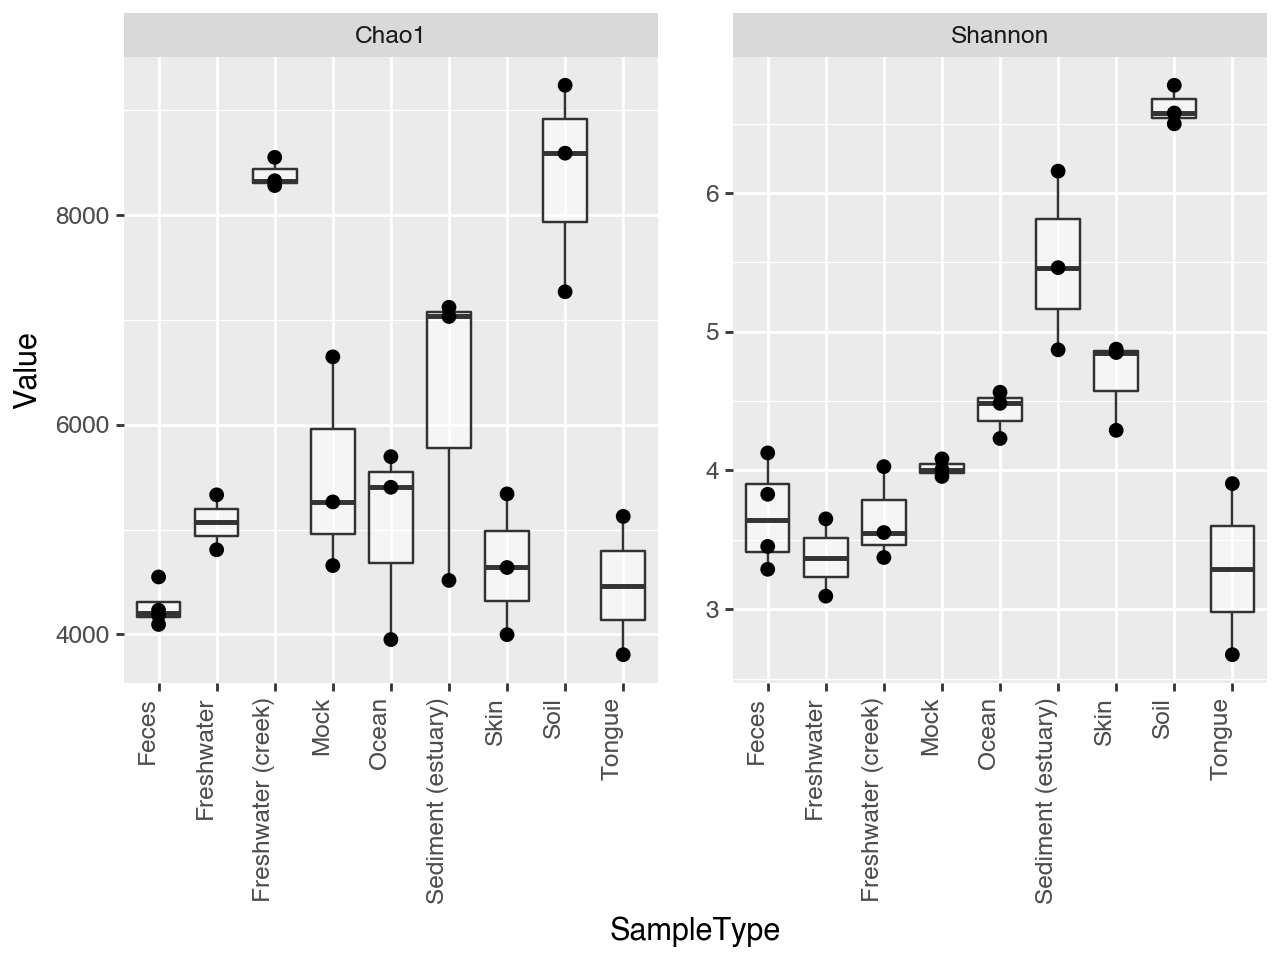

In [11]:
p = plot_richness(gp, x="SampleType", measures=["Shannon", "Chao1"])
display(p)